<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F06_hierarchical_reconciliation.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 06 · Coherent Hierarchical Forecasting (`S` Matrix & 7 FPP3 Reconciliation Methods)

Enterprise organizations require forecasts that add up coherently across product, geography, and organizational hierarchies (`__total__` $\rightarrow$ `region` $\rightarrow$ `region/category` $\rightarrow$ `ts_id`). `scale-forecasting` implements full bottom-up aggregation and post-forecast projection $\tilde{y} = S G \hat{y}$ across all **7 Hyndman FPP3 reconciliation estimators** (`reconciliation.py`):

| Method | Formula / Weighting | When to Use |
| :--- | :--- | :--- |
| **`bottom_up`** | Sums bottom-level forecasts directly ($G = [0 \mid I]$) | High signal-to-noise bottom series; zero aggregate model bias |
| **`top_down`** | Disaggregates `__total__` forecast by historical average proportions $p_i$ | Noisy bottom series with stable macro proportions |
| **`middle_out`** | Anchors at an intermediate `middle_level`, sums up & disaggregates down | Strong regional/category signal |
| **`ols`** | Identity error covariance ($W = I$) ordinary least squares projection | Fast coherence without backtest residuals |
| **`wls_struct`** | Structural variance scaling ($W = \text{diag}(S \mathbf{1})$) | Balanced accuracy across hierarchy levels without OOF residuals |
| **`wls_var`** | Diagonal out-of-fold residual variance ($W = \text{diag}(\hat{\sigma}_i^2)$) | Heteroskedastic series with backtesting enabled |
| **`mint_shrink`** | Schafer-Strimmer shrinkage covariance of OOF residuals ($W = \hat{\Sigma}_{\text{shrink}}$) | **Gold standard** — exploits cross-series error correlations |

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Configure Hierarchical Forecasting & Explain the Plan

We configure `hierarchy={'enabled': True, 'levels': [['region'], ['region', 'category']], 'reconciliation_methods': ['bottom_up', 'wls_struct', 'mint_shrink']}` so the engine automatically rolls up the panel before model fitting and reconciles both out-of-fold backtest predictions and future forecasts.

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

# === Parameters — edit me ===============================================
RUN_NAME = f"nb06 hierarchy mint {int(time.time())}"
SOURCE_TABLE = "source_series_covariates_native"  # includes region & category hierarchy columns
MODELS = ["theta", "holtwinters", "lightgbm"]
RECON_METHODS = ["bottom_up", "wls_struct", "mint_shrink"]
HORIZON = 14
SERIES_LIMIT = 20
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="vertex",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,
    hierarchy={
        "enabled": True,
        "levels": [["region"], ["region", "category"]],
        "reconciliation_methods": RECON_METHODS,
    },
    backtest={"enabled": True, "n_folds": 2, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ["inverse_error", "nnls"]},
)

forecaster = Forecaster(cfg, settings=settings)
print("run_id:", forecaster.run_id)
display(forecaster.explain(validate_data=False))

run_id: nb06-hierarchy-mint-1791145253-bbc069a2c659


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb06-hierarchy-mint-1791145253-bbc069a2c659,statistical,sf-nb06-hierarchy-mint-1791145253-bbc069a2c659...,vertex,n2-standard-8,1,cpu,None,"theta, holtwinters","theta:local, holtwinters:local",20,2,40,none,
1,nb06-hierarchy-mint-1791145253-bbc069a2c659,ml,sf-nb06-hierarchy-mint-1791145253-bbc069a2c659...,vertex,n2-standard-8,1,cpu,None,lightgbm,lightgbm:local,20,2,20,none,
2,nb06-hierarchy-mint-1791145253-bbc069a2c659,ensemble,sf-nb06-hierarchy-mint-1791145253-bbc069a2c659...,bigquery,sql,1,sql,None,"ensemble_inverse_error, ensemble_nnls",barrier,20,2,40,none,sf-nb06-hierarchy-mint-1791145253-bbc069a2c659...


## Act 3 · Launch & Monitor Live (`forecaster.run_live()`)

During execution, the worker engine augments the 20 bottom series with their aggregate parent nodes (`__total__`, `region=*`, `region=*/category=*`), fits each model, reconciles every model's forecasts across `bottom_up`, `wls_struct`, and `mint_shrink`, and writes the coherent forecasts to BigQuery.

Completed nb06-hierarchy-mint-1791145253-bbc069a2c659: status=COMPLETED, runtime=427.4s


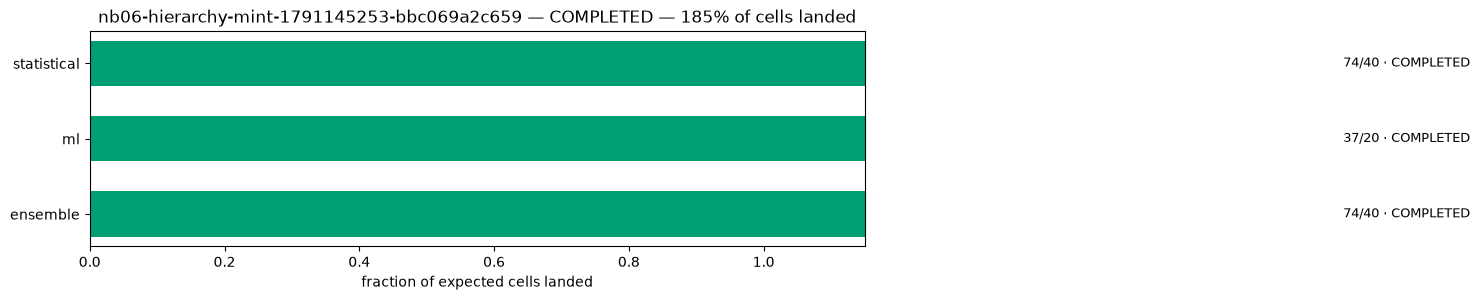

In [4]:
result = forecaster.run_live(poll_s=15.0, probe=True)
print(f"Completed {result.run_id}: status={result.status}, runtime={result.runtime_seconds:.1f}s")

## Act 4 · Inspect Hierarchy Level Rollups (`hierarchy_df` & `plot_hierarchy`)

`forecaster.hierarchy_df()` and `forecaster.plot_hierarchy()` aggregate predicted totals across each level of the tree (`level_0_total`, `level_1`, `level_2`, `bottom_or_leaf`) to verify that every level sums to the exact same grand total.

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,holtwinters_mint_shrink,unknown,False,None,vertex,37,wape,0.290296,0.101042,...,19.777619,29.661252,0.686293,112.278367,1.656038,1.460099,1.0,518,NaN,NaN
1,2,holtwinters_bottom_up,unknown,False,None,vertex,37,wape,0.300555,0.103318,...,21.299447,31.538323,0.622587,118.562089,1.656038,1.460099,1.0,518,NaN,NaN
2,3,holtwinters,statistical,False,None,vertex,37,wape,0.302522,0.100471,...,21.196424,28.973053,0.666023,108.865936,1.656038,1.460099,1.0,518,NaN,NaN
3,4,lightgbm_mint_shrink,unknown,False,None,vertex,37,wape,0.305898,0.092156,...,17.987551,26.310532,0.277992,137.620348,1.015369,0.821361,1.0,518,NaN,NaN
4,5,ensemble_inverse_error,ensemble,True,34432fdde9fa,ensemble,37,wape,0.306834,0.095035,...,19.474818,27.197892,NaN,NaN,NaN,NaN,1.0,518,-0.016538,-0.056969
5,6,holtwinters_wls_struct,unknown,False,None,vertex,37,wape,0.312112,0.097846,...,20.821935,31.072354,0.596525,128.089127,1.656038,1.460099,1.0,518,NaN,NaN
6,7,theta_mint_shrink,unknown,False,None,vertex,37,wape,0.322315,0.109499,...,21.620279,31.275288,0.989382,234.936310,1.899232,1.767336,1.0,518,NaN,NaN
7,8,ensemble_nnls,ensemble,True,34432fdde9fa,ensemble,37,wape,0.325074,0.097184,...,20.193194,27.936101,NaN,NaN,NaN,NaN,0.0,518,-0.034778,-0.119801
8,9,lightgbm_bottom_up,unknown,False,None,vertex,37,wape,0.331109,0.099090,...,19.987410,28.746893,0.302124,144.084096,1.015369,0.821361,1.0,518,NaN,NaN
9,10,theta_bottom_up,unknown,False,None,vertex,37,wape,0.332475,0.110100,...,22.993494,33.070271,0.991313,248.964410,1.899232,1.767336,1.0,518,NaN,NaN


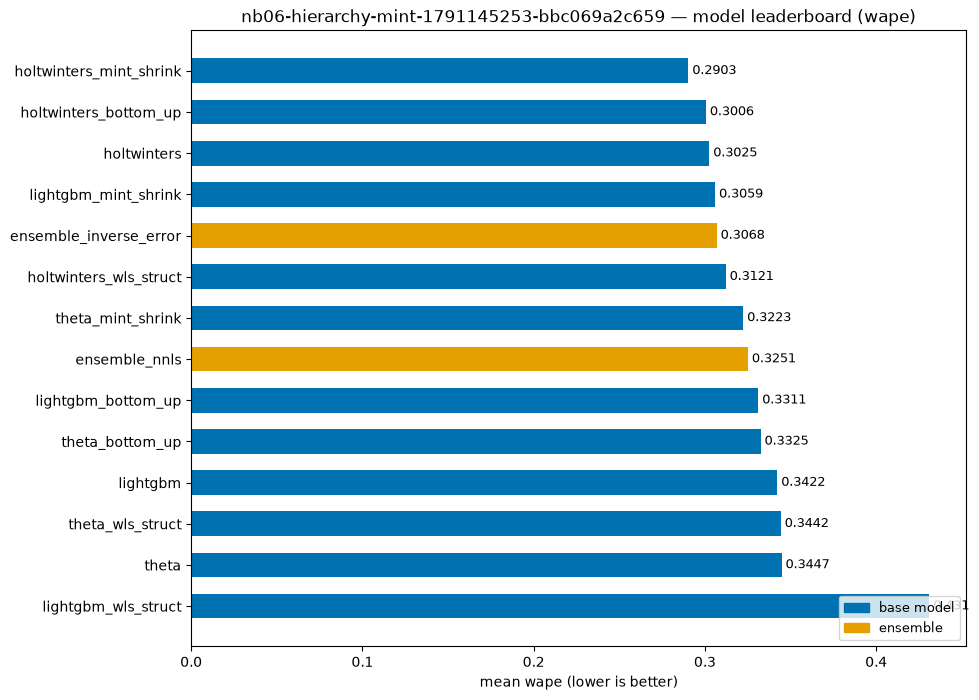

,model_type,level,n_series,n_points,mean_yhat,sum_yhat,max_coherence_residual
0,ensemble_inverse_error,total,1,14,2041.509304,28581.130250,2371.577086
1,ensemble_inverse_error,aggregate,12,168,164.653247,27661.745572,2371.577086
2,ensemble_inverse_error,bottom,24,336,169.578190,56978.271966,2371.577086
3,ensemble_nnls,total,1,14,2033.259359,28465.631027,2416.344445
4,ensemble_nnls,aggregate,12,168,167.466891,28134.437675,2416.344445
5,ensemble_nnls,bottom,24,336,171.745269,57706.410389,2416.344445
6,holtwinters,total,1,14,2055.259926,28773.638965,2308.194808
7,holtwinters,aggregate,12,168,161.011573,27049.944294,2308.194808
8,holtwinters,bottom,24,336,167.203356,56180.327709,2308.194808
9,holtwinters_bottom_up,total,1,14,1915.234532,26813.283446,2259.492074


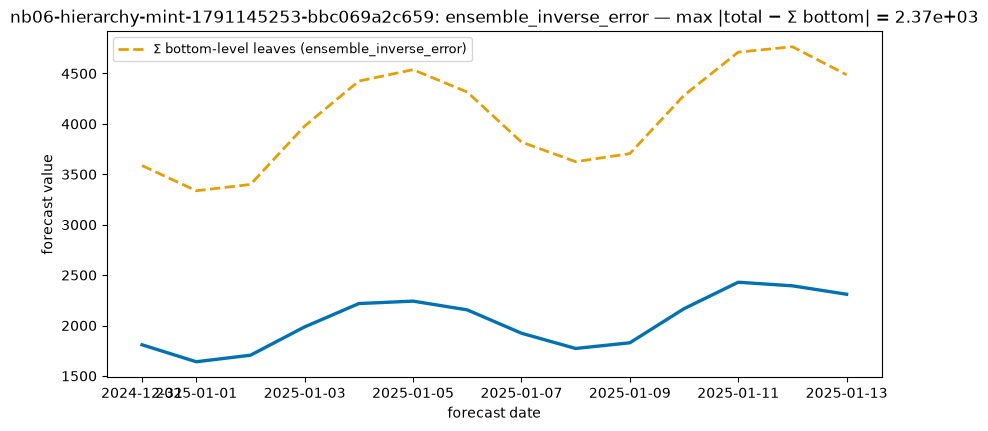

In [5]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard

display(forecaster.leaderboard_df())
plot_leaderboard(forecaster.review_run())
plt.show()

h_df = forecaster.hierarchy_df()
display(h_df)

forecaster.plot_hierarchy()
plt.show()